In [23]:
# Load images

import digiagro_helper as helper
import torch
import numpy as np
import alvq
import lvq_p_train
from tqdm import tqdm
import matplotlib.pyplot as plt

img_dir = '../../Croptimal/2024_5_13_CleansingDataset/Run1_light_normal_otherobjects/train/'

class_subdirs = [
    # Class 0
    # (subdir, weight)
    [('sobel_class_0', 1.0)],
    # Class 1
    [('sobel_class_1', 1.0)]]

n_classes = len(class_subdirs)
global_imgs = helper.read_imgs(img_dir, class_subdirs)

for i in range(n_classes):
    print(f'Loaded {len(global_imgs[i])} images for class {i}')

Loaded 2258 images for class 0
Loaded 1390 images for class 1


100%|██████████| 2000/2000 [01:28<00:00, 22.58it/s]


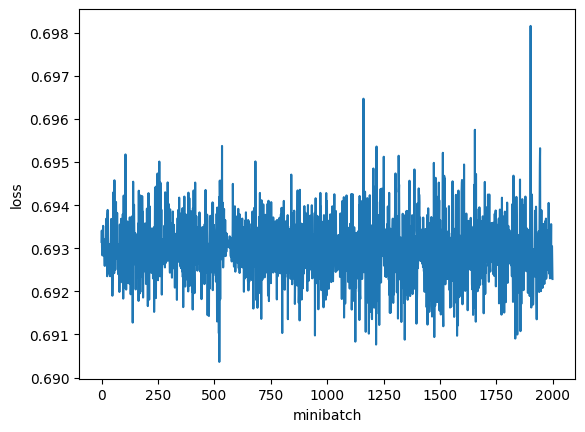

In [24]:
# Check how many minibatches are needed to train

minibatch_sz = 1000
n_minibatches = 2000

imgs_train, imgs_val = helper.xval(global_imgs)
train_loader = helper.data_loader(imgs_train, minibatch_sz)

mu, std = helper.feats_mean_std(train_loader, n_minibatches // 10)
mu = torch.from_numpy(mu)
std = torch.from_numpy(std)

n_feats = mu.shape[0]
init_protos = torch.from_numpy(np.ones((2, n_feats), dtype=np.float32))

net = alvq.alvq_net(n_feats, init_protos, False, mu, std)
lvq = lvq_p_train.lvq_p_train(net, lr=0.001)

losses = np.empty(n_minibatches)

for batch_nr in tqdm(range(n_minibatches)):
    X, y = next(train_loader)
    X = torch.from_numpy(X)
    y = torch.from_numpy(y)        
    losses[batch_nr] = lvq.train(X, y)

plt.plot(losses)
plt.xlabel('minibatch')
plt.ylabel('loss');

In [3]:
# Train probabilistic angular LVQ

minibatch_sz = 1000
n_minibatches = 1000
# Increase to decrease the variance in the average validation accuracy
n_runs = 10
val_accs = np.zeros(n_runs)

for data_split_nr in tqdm(range(n_runs)):
    imgs_train, imgs_val = helper.xval(global_imgs)

    train_loader = helper.data_loader(imgs_train, minibatch_sz)
   
    mu, std = helper.feats_mean_std(train_loader, n_minibatches // 10)

    mu = torch.from_numpy(mu)
    std = torch.from_numpy(std)

    n_feats = mu.shape[0]
    init_protos = torch.from_numpy(np.ones((2, n_feats), dtype=np.float32))
    
    net = alvq.alvq_net(n_feats, init_protos, False, mu, std)
    lvq = lvq_p_train.lvq_p_train(net, lr=0.001)
    
    for batch_nr in range(n_minibatches):
        X, y = next(train_loader)
        X = torch.from_numpy(X)
        y = torch.from_numpy(y)        
        lvq.train(X, y)
        
    val_loader = helper.data_loader(imgs_val, minibatch_sz)    
    X, y = next(val_loader) # just 1 minibatch    

    X = torch.from_numpy(X)
    y = torch.from_numpy(y)
    y_pred = lvq.inference(X)
    val_accs[data_split_nr] = (y_pred == y).sum() / y.shape[0]

print(f'avg val acc: {val_accs.mean():.4f} ± {val_accs.std():.4f}')

100%|██████████| 10/10 [08:00<00:00, 48.05s/it]

avg val acc: 0.5139 ± 0.0141


In [20]:
# Train on all images

minibatch_sz = 1000
n_minibatches = 1000

train_loader = helper.data_loader(global_imgs, minibatch_sz)
   
mu, std = helper.feats_mean_std(train_loader, n_minibatches // 10)

mu = torch.from_numpy(mu)
std = torch.from_numpy(std)

n_feats = mu.shape[0]
init_protos = torch.from_numpy(np.ones((2, n_feats), dtype=np.float32))

net = alvq.alvq_net(n_feats, init_protos, False, mu, std)
lvq = lvq_p_train.lvq_p_train(net, lr=0.001)
    
for batch_nr in range(n_minibatches):
    X, y = next(train_loader)
    X = torch.from_numpy(X)
    y = torch.from_numpy(y)        
    lvq.train(X, y)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


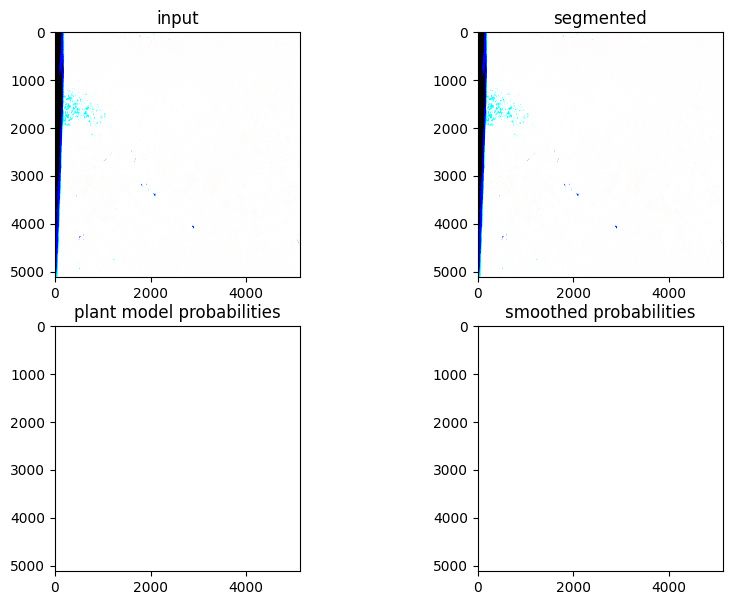

In [22]:
# Test image in the testing dataset

# Parameters

ds = 8            # downscale factor for probability smoothing
p_threshold = 0.5 # (average) probability threshold

import cv2
import skimage.io

img = skimage.io.imread("../../Croptimal/2024_5_13_CleansingDataset/Run1_light_normal_otherobjects/test/4e8ef493-3884-4645-82c6-4291a576684d.png")
# # set to grayscale
# img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# apply sobel filter to the image
sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
img = cv2.magnitude(sobelx, sobely).astype(np.float32)  # ensure float32 for PyTorch
width = img.shape[1]
height = img.shape[0]

with torch.no_grad():
    scalar = net.probabilities(torch.from_numpy(img))

scalar = scalar[..., 1].reshape(img.shape[0:2]).detach()
scalar_orig = scalar
scalar = cv2.resize(scalar.numpy(), (width // ds, height // ds), interpolation=cv2.INTER_AREA)
scalar = cv2.resize(scalar, (width, height), interpolation=cv2.INTER_LINEAR)

fig, axes = plt.subplots(2, 2, figsize=(10,7))
axes[0][0].imshow(img)
axes[0][0].set_title('input')
img2 = img.copy()
img2[scalar < p_threshold, :] = 0
axes[0][1].imshow(img2)
axes[0][1].set_title('segmented')
axes[1][0].imshow(scalar_orig)
axes[1][0].set_title('plant model probabilities')
axes[1][1].imshow(scalar)
axes[1][1].set_title('smoothed probabilities');


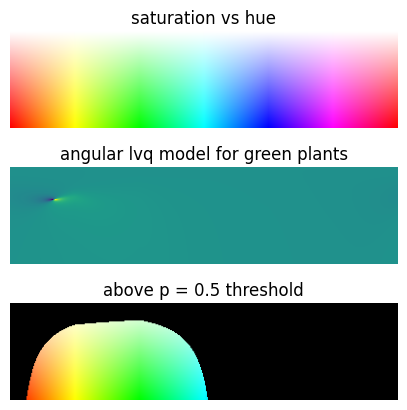

In [ ]:
# Check which colors are classified as plants

hue = np.linspace(0, 360, 400, dtype=np.float32)
sat = np.linspace(0, 1, 100, dtype=np.float32)
val = 1 * np.ones((100, 400), dtype=np.float32)
x, y = np.meshgrid(hue, sat)

vals = np.stack((x, y, val), 2)

img = cv2.cvtColor(vals, cv2.COLOR_HSV2RGB)

with torch.no_grad():
    scalar = net.probabilities(torch.from_numpy(img))

scalar = scalar[..., 1].reshape(img.shape[0:2])

fig, axes = plt.subplots(3, 1, figsize=(5,5))
axes[0].imshow(img)
axes[0].set_title('saturation vs hue')
axes[0].set_axis_off()
axes[1].set_title('angular lvq model for green plants')
axes[1].imshow(scalar)
axes[1].set_axis_off()
img[scalar < p_threshold, :] = 0
axes[2].set_title(f'above p = {p_threshold} threshold')
axes[2].imshow(img)
axes[2].set_axis_off();